머신러닝 모델링

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore') # 가독성을 위해 불필요한 경고 메시지 차단

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score
from imblearn.over_sampling import SMOTE  # 5.6%의 취소 데이터 학습을 위한 오버샘플링
from imblearn.pipeline import Pipeline     # 데이터 누수(Data Leakage) 방지용 파이프라인

# 10대 머신러닝 모델 라이브러리 소환
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df= pd.read_csv('../data/preprocessed/hotel_bookings.csv')

In [6]:
df.head()

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,reservation_date,diff_reserved_room_type
0,Resort Hotel,0,342,0,0,2,0.0,0,BB,PRT,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,2014-07-24,False
1,Resort Hotel,0,737,0,0,2,0.0,0,BB,PRT,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,2013-06-24,False
2,Resort Hotel,0,7,0,1,1,0.0,0,BB,GBR,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,2015-06-24,True
3,Resort Hotel,0,13,0,1,1,0.0,0,BB,GBR,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,2015-06-18,False
4,Resort Hotel,0,14,0,2,2,0.0,0,BB,GBR,...,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01,2015-06-17,False


In [ ]:
df.isna().sum()

In [ ]:
df.info()

10개의 모델 예선전

In [ ]:
df = pd.read_csv(r'C:\Users\gkgke\Desktop\SKN30-2nd-3Team\data\preprocessed\hotel_bookings.csv')
drop_cols = ['reservation_status', 'reservation_status_date', 'arrival_date', 'reservation_date']
X = df.drop(columns=[col for col in drop_cols if col in df.columns] + ['is_canceled'])
y = df['is_canceled']
X = pd.get_dummies(X, drop_first=True)


models = {
    'LightGBM': LGBMClassifier(n_jobs=-1, random_state=1004, verbose=-1),
    'XGBoost': XGBClassifier(n_jobs=-1, random_state=1004, eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(random_state=1004, verbose=0, allow_writing_files=False),
    'RandomForest': RandomForestClassifier(n_jobs=-1, random_state=1004),
    'GradientBoosting': GradientBoostingClassifier(random_state=1004),
    'DecisionTree': DecisionTreeClassifier(random_state=1004),
    'AdaBoost': AdaBoostClassifier(random_state=1004),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=1004),
    'GaussianNB': GaussianNB(),
    'LinearDiscriminantAnalysis': LinearDiscriminantAnalysis()
}


cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1004)
results = []


for name, model in models.items():
    
    pipeline = Pipeline([
        ('smote', SMOTE(random_state=1004)),
        ('classifier', model)
    ])
    
    recalls, precisions, f1s = [], [], []
    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)
        
        recalls.append(recall_score(y_val, y_pred))
        precisions.append(precision_score(y_val, y_pred))
        f1s.append(f1_score(y_val, y_pred))
        
    results.append({
        'Model': name,
        'Recall': sum(recalls) / len(recalls),
        'Precision': sum(precisions) / len(precisions),
        'F1-Score': sum(f1s) / len(f1s)
    })
    print(f"{name} 검증 완료")

df_results = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
print("\n[10대 모델 통합 성능 비교 성적표]")
display(df_results)

🚀 랜덤 시드 기반 10대 모델 정면 승부를 시작합니다! (약 16분 소요)
✅ LightGBM 검증 완료!
✅ XGBoost 검증 완료!
✅ CatBoost 검증 완료!
✅ RandomForest 검증 완료!
✅ GradientBoosting 검증 완료!
✅ DecisionTree 검증 완료!
✅ AdaBoost 검증 완료!
✅ LogisticRegression 검증 완료!
✅ GaussianNB 검증 완료!
✅ LinearDiscriminantAnalysis 검증 완료!

📊 [최종 10대 모델 통합 성능 비교 성적표 - Seed 1004]


,Model,Recall,Precision,F1-Score
0,RandomForest,0.835428,0.861237,0.848124
1,CatBoost,0.831963,0.830853,0.831401
2,XGBoost,0.830061,0.816350,0.823139
3,LightGBM,0.826233,0.810969,0.818511
4,DecisionTree,0.825554,0.800406,0.812775
5,GradientBoosting,0.802885,0.781558,0.792064
6,AdaBoost,0.782525,0.755407,0.768636
7,LogisticRegression,0.748239,0.745131,0.746658
8,LinearDiscriminantAnalysis,0.679598,0.786916,0.729316
9,GaussianNB,0.899608,0.488175,0.632699


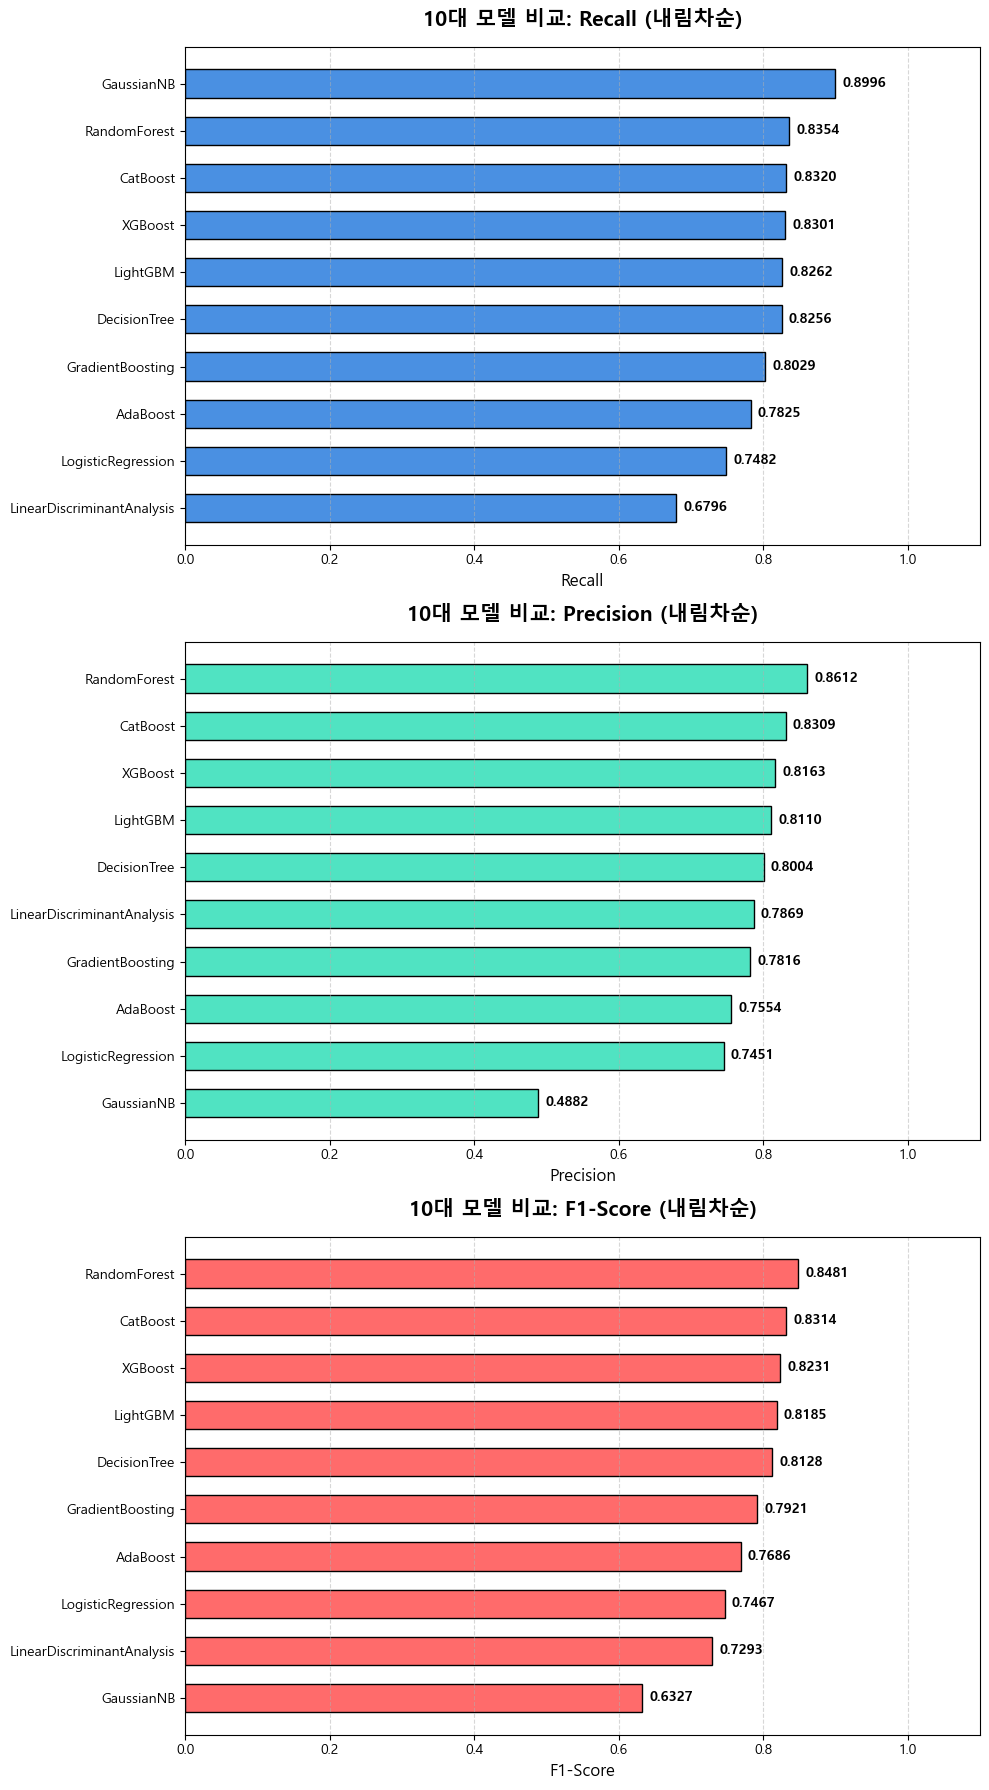

In [28]:
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

metrics = ['Recall', 'Precision', 'F1-Score']
colors = ['#4A90E2', '#50E3C2', '#FF6B6B']


fig, axes = plt.subplots(3, 1, figsize=(10, 18))

for i, metric in enumerate(metrics):
    df_sorted = df_results.sort_values(by=metric, ascending=True)
    bars = axes[i].barh(df_sorted['Model'], df_sorted[metric], color=colors[i], edgecolor='black', height=0.6)
    
    
    axes[i].set_title(f'10대 모델 비교: {metric} (내림차순)', fontsize=15, fontweight='bold', pad=15)
    axes[i].set_xlabel(metric, fontsize=12)
    axes[i].set_xlim(0, 1.1)
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)
    
    for bar in bars:
        width = bar.get_width()
        axes[i].text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
                     va='center', ha='left', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [29]:
# 데이터 로드 및 전처리
df = pd.read_csv(r'C:\Users\gkgke\Desktop\SKN30-2nd-3Team\data\preprocessed\hotel_bookings.csv')
drop_cols = ['reservation_status', 'reservation_status_date', 'arrival_date', 'reservation_date']
X = df.drop(columns=[col for col in drop_cols if col in df.columns] + ['is_canceled'])
y = df['is_canceled']
X = pd.get_dummies(X, drop_first=True)


models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=2026),
    'RandomForest': RandomForestClassifier(n_jobs=-1, random_state=2026),
    'XGBoost': XGBClassifier(n_jobs=-1, random_state=2026, eval_metric='logloss')
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=2026)
results = []

print("3개 후보 모델 검증을 시작합니다. (Stratified 10-Fold + SMOTE)")

for name, model in models.items():
    pipeline = Pipeline([
        ('smote', SMOTE(random_state=2026)),
        ('classifier', model)
    ])
    
    recalls, precisions, f1s = [], [], []
    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)
        
        recalls.append(recall_score(y_val, y_pred))
        precisions.append(precision_score(y_val, y_pred))
        f1s.append(f1_score(y_val, y_pred))
        
    results.append({
        'Model': name,
        'Recall': sum(recalls) / len(recalls),
        'Precision': sum(precisions) / len(precisions),
        'F1-Score': sum(f1s) / len(f1s)
    })
    print(f"{name} 검증 완료")

df_results = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
print("\n[후보 모델 성능 비교 성적표]")
display(df_results)

3개 후보 모델 검증을 시작합니다. (Stratified 10-Fold + SMOTE)
LogisticRegression 검증 완료
RandomForest 검증 완료
XGBoost 검증 완료

[후보 모델 성능 비교 성적표]


,Model,Recall,Precision,F1-Score
0,RandomForest,0.837851,0.860677,0.849101
1,XGBoost,0.830197,0.815214,0.822625
2,LogisticRegression,0.745952,0.745921,0.745919


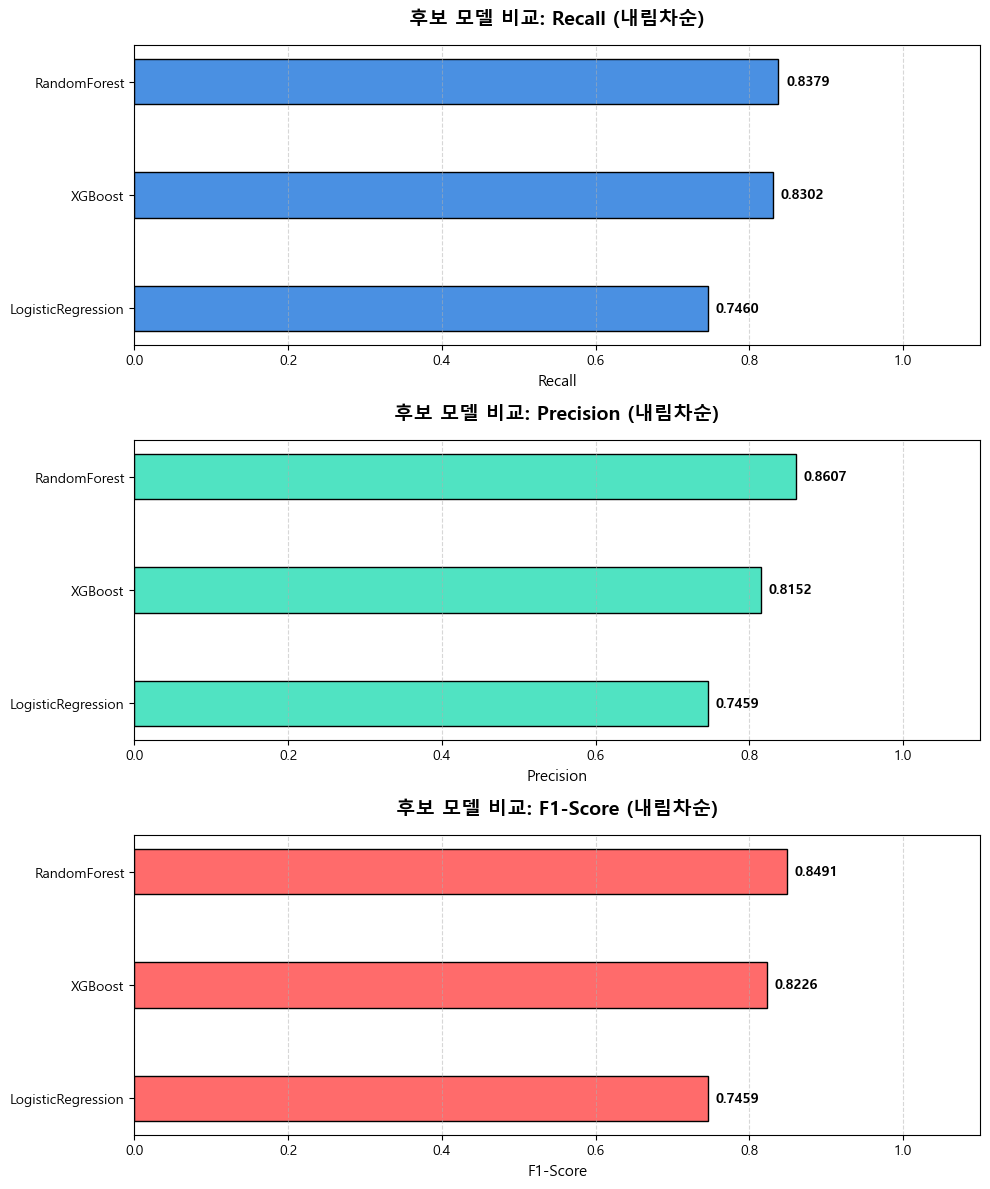

In [30]:
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

metrics = ['Recall', 'Precision', 'F1-Score']
colors = ['#4A90E2', '#50E3C2', '#FF6B6B']

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, metric in enumerate(metrics):
    df_sorted = df_results.sort_values(by=metric, ascending=True)
    bars = axes[i].barh(df_sorted['Model'], df_sorted[metric], color=colors[i], edgecolor='black', height=0.4)
    
    axes[i].set_title(f'후보 모델 비교: {metric} (내림차순)', fontsize=14, fontweight='bold', pad=15)
    axes[i].set_xlabel(metric, fontsize=11)
    axes[i].set_xlim(0, 1.1)
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)
    
    for bar in bars:
        width = bar.get_width()
        axes[i].text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
                     va='center', ha='left', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

전처리 코드 추가 후 다시 확인

In [31]:
from sklearn.preprocessing import StandardScaler  # 스케일러 추가

# 1. 데이터 로드 및 전처리
df = pd.read_csv(r'C:\Users\gkgke\Desktop\SKN30-2nd-3Team\data\preprocessed\hotel_bookings.csv')
drop_cols = ['reservation_status', 'reservation_status_date', 'arrival_date', 'reservation_date']
X = df.drop(columns=[col for col in drop_cols if col in df.columns] + ['is_canceled'])
y = df['is_canceled']
X = pd.get_dummies(X, drop_first=True)

# 2. 10대 모델 라인업 정의 (시드 2026 고정)
models = {
    'LightGBM': LGBMClassifier(n_jobs=-1, random_state=2026, verbose=-1),
    'XGBoost': XGBClassifier(n_jobs=-1, random_state=2026, eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(random_state=2026, verbose=0, allow_writing_files=False),
    'RandomForest': RandomForestClassifier(n_jobs=-1, random_state=2026),
    'GradientBoosting': GradientBoostingClassifier(random_state=2026),
    'DecisionTree': DecisionTreeClassifier(random_state=2026),
    'AdaBoost': AdaBoostClassifier(random_state=2026),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=2026),
    'GaussianNB': GaussianNB(),
    'LinearDiscriminantAnalysis': LinearDiscriminantAnalysis()
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=2026)
results = []

print("10개의 모델 과적합 방지를 포함한 검증 시작")


for name, model in models.items():
    # 파이프라인 맨 앞에 StandardScaler를 배치하여 모든 모델에 일괄 적용
    pipeline = Pipeline([
        ('scaler', StandardScaler()),  
        ('smote', SMOTE(random_state=2026)),
        ('classifier', model)
    ])
    
    train_f1s, val_f1s = [], []
    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        pipeline.fit(X_train, y_train)
        
        y_train_pred = pipeline.predict(X_train)
        y_val_pred = pipeline.predict(X_val)
        
        train_f1s.append(f1_score(y_train, y_train_pred))
        val_f1s.append(f1_score(y_val, y_val_pred))
        
    results.append({
        'Model': name,
        'Train F1-Score': sum(train_f1s) / len(train_f1s),
        'Val F1-Score': sum(val_f1s) / len(val_f1s),
        'Gap': (sum(train_f1s) / len(train_f1s)) - (sum(val_f1s) / len(val_f1s))
    })
    print(f"{name} 검증 완료")

df_overfit_check = pd.DataFrame(results).sort_values(by='Val F1-Score', ascending=False).reset_index(drop=True)
print("\n[10개 모델의 평가지표]")
display(df_overfit_check)


10개의 모델 과적합 방지를 포함한 검증 시작
LightGBM 검증 완료
XGBoost 검증 완료
CatBoost 검증 완료
RandomForest 검증 완료
GradientBoosting 검증 완료
DecisionTree 검증 완료
AdaBoost 검증 완료
LogisticRegression 검증 완료
GaussianNB 검증 완료
LinearDiscriminantAnalysis 검증 완료

[10개 모델의 평가지표]


,Model,Train F1-Score,Val F1-Score,Gap
0,RandomForest,0.993720,0.847787,0.145933
1,CatBoost,0.847684,0.831968,0.015716
2,XGBoost,0.838786,0.825415,0.013371
3,LightGBM,0.827138,0.821353,0.005785
4,DecisionTree,0.993731,0.812510,0.181221
5,GradientBoosting,0.795676,0.794545,0.001131
6,AdaBoost,0.762009,0.761756,0.000254
7,LogisticRegression,0.757528,0.756555,0.000973
8,LinearDiscriminantAnalysis,0.751941,0.750761,0.001180
9,GaussianNB,0.570652,0.569797,0.000856


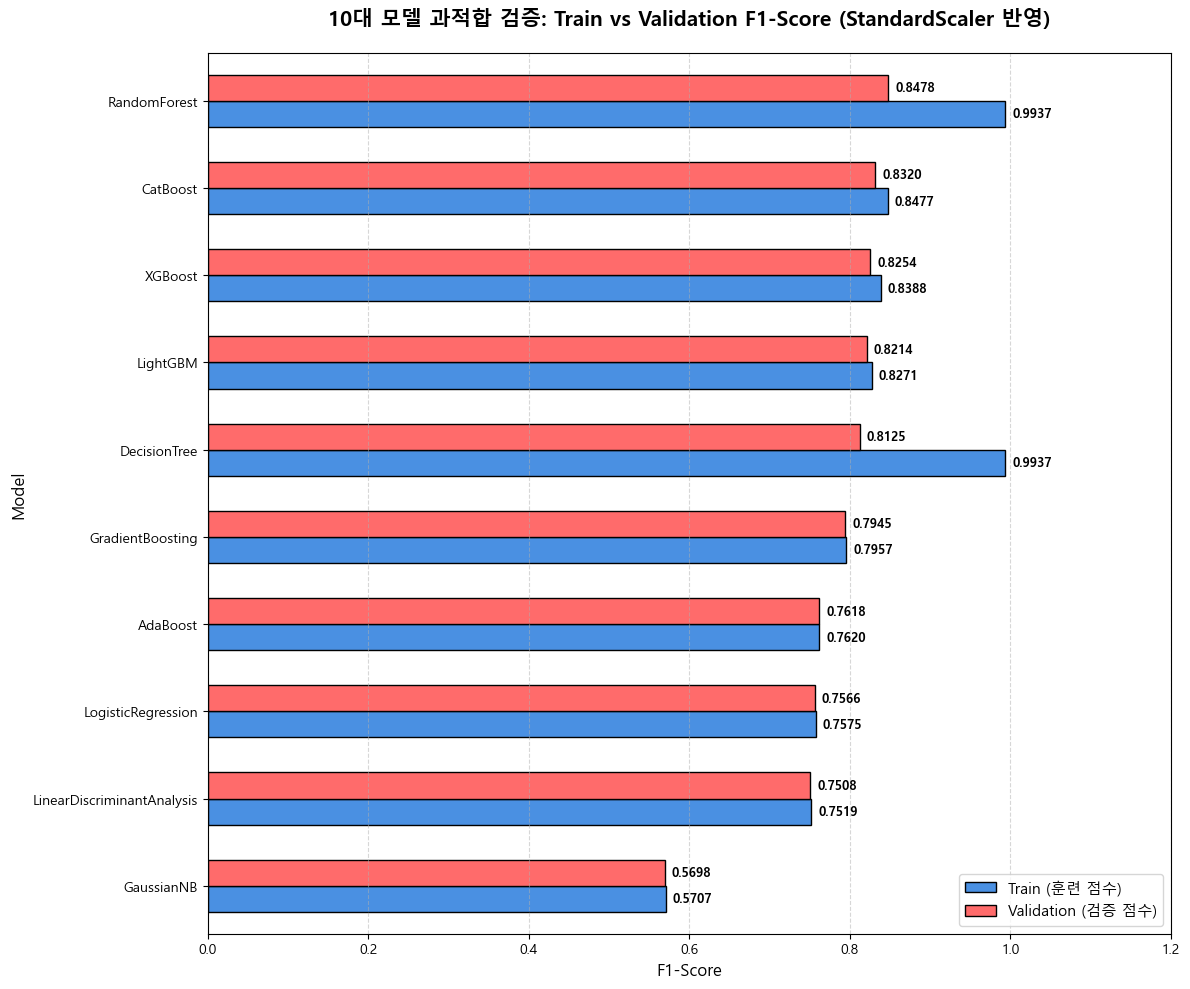

In [32]:

# 가로막대 시각화
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False


df_plot = df_overfit_check.set_index('Model').sort_values(by='Val F1-Score', ascending=True)


ax = df_plot[['Train F1-Score', 'Val F1-Score']].plot(
    kind='barh', 
    figsize=(12, 10), 
    color=['#4A90E2', '#FF6B6B'],  
    edgecolor='black',
    width=0.6
)

plt.title('10대 모델 과적합 검증: Train vs Validation F1-Score (StandardScaler 반영)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('F1-Score', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0, 1.2)  
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(['Train (훈련 점수)', 'Validation (검증 점수)'], loc='lower right', fontsize=11)

# 각 막대 끝에 수치 라벨 추가
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=5, fontproperties={'weight': 'bold', 'size': 9})

plt.tight_layout()
plt.show()

데이터 문제로 새로 돌려봐야함